# Hyperparameter Tuning & Threshold Optimization

Building on the advanced models (best AUC ≈ 0.817), we:
1. **Tune hyperparameters** for XGBoost and LightGBM via RandomizedSearchCV
2. **Optimize the decision threshold** to maximize F1 or balance precision/recall

## Strategy
- Tune on a 300k stratified subsample with 3-fold temporal CV
- Evaluate best model on full Nov–Dec test set
- Compare default threshold (0.5) vs optimized threshold

## Step 0: Setup

In [1]:
import sys
from pathlib import Path

_here = Path.cwd().resolve()
for _p in [_here] + list(_here.parents):
    if (_p / "notebooks" / "project_data.py").exists():
        sys.path.insert(0, str(_p / "notebooks"))
        break

from project_data import ensure_project_data
ensure_project_data()

[data] Already present: /Users/jeffvan/Desktop/My Stuff/Courses/CIS5450/CIS-5450/data


PosixPath('/Users/jeffvan/Desktop/My Stuff/Courses/CIS5450/CIS-5450/data')

In [2]:
import os, re, warnings, time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix,
    RocCurveDisplay, PrecisionRecallDisplay,
    precision_recall_curve, make_scorer,
)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from project_data import resolve_project_root

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

PROJECT_ROOT = resolve_project_root()
DATA_ROOT = Path(os.getenv("FLIGHT_DATA_DIR", PROJECT_ROOT / "data")).expanduser().resolve()
INTEGRATED_DIR = DATA_ROOT / "processed" / "integrated"
REPORT_DIR = DATA_ROOT / "reports" / "modeling"
REPORT_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_parquet(INTEGRATED_DIR / "features_2024.parquet")
df["FlightDate"] = pd.to_datetime(df["FlightDate"])
print(f"Loaded {len(df):,} rows, {len(df.columns)} columns")

Loaded 6,817,598 rows, 81 columns


## Step 1: Feature matrix (same as advanced model)

In [3]:
TARGET = "DepDel15"

NUMERIC_FEATURES = [
    "CRSDepTime", "CRSArrTime", "CRSElapsedTime", "Distance",
    "dep_hour", "month", "day_of_week", "is_weekend",
    "is_holiday", "holiday_proximity",
    "is_origin_hub", "is_dest_hub",
    "airline_delay_rate_7d", "origin_delay_rate_7d", "route_delay_rate_7d",
    "origin_daily_flights",
    "prev_flight_arr_delay", "tail_leg_today",
    "origin_hourly_flights",
    "origin_air_temp", "origin_dew_point", "origin_sea_level_pres",
    "origin_wind_dir", "origin_wind_speed", "origin_sky_cover",
    "origin_precip_1h", "origin_precip_6h",
    "origin_weather_severity",
    "origin_freezing_rain", "origin_wind_rain", "origin_fog_risk",
    "dest_air_temp", "dest_dew_point", "dest_sea_level_pres",
    "dest_wind_dir", "dest_wind_speed", "dest_sky_cover",
    "dest_precip_1h", "dest_precip_6h",
    "dest_weather_severity",
    "dest_freezing_rain", "dest_wind_rain", "dest_fog_risk",
    "worst_precip", "worst_wind",
    "origin_is_rain", "origin_high_wind", "origin_freezing", "origin_low_vis",
    "dest_is_rain", "dest_high_wind", "dest_freezing", "dest_low_vis",
]

def top_n_encode(series, n=30):
    top = series.value_counts().nlargest(n).index
    return series.where(series.isin(top), "OTHER")

df["Origin_enc"] = top_n_encode(df["Origin"].astype(str), 30)
df["Dest_enc"] = top_n_encode(df["Dest"].astype(str), 30)

cat_encode_cols = ["Reporting_Airline", "Origin_enc", "Dest_enc", "time_block", "distance_bin"]
dummies = pd.get_dummies(df[cat_encode_cols].astype(str), drop_first=True, dtype=int)

X = pd.concat([df[NUMERIC_FEATURES], dummies], axis=1)
X = X.fillna(X.median())
for col in X.columns:
    X[col] = pd.to_numeric(X[col], errors="coerce").astype(np.float64)
X.columns = [re.sub(r'[\[\]<]', '_', c) for c in X.columns]

print(f"Features: {X.shape[1]}")

Features: 134


## Step 2: Train/test split

In [4]:
train_mask = df["month"] <= 10
test_mask = df["month"] >= 11

y_test = df.loc[test_mask, TARGET].astype(np.int64)
y_full_train = df.loc[train_mask, TARGET].astype(np.int64)

# Stratified subsample for tuning (300k — fast CV)
TUNE_SAMPLE = 300_000
rng = np.random.RandomState(42)
train_idx_full = df.index[train_mask]
pos_idx = train_idx_full[y_full_train == 1]
neg_idx = train_idx_full[y_full_train == 0]
ratio = len(pos_idx) / len(train_idx_full)
n_pos = int(TUNE_SAMPLE * ratio)
n_neg = TUNE_SAMPLE - n_pos
tune_idx = pd.Index(np.concatenate([
    rng.choice(pos_idx, n_pos, replace=False),
    rng.choice(neg_idx, n_neg, replace=False),
]))

X_tune = X.loc[tune_idx].copy()
y_tune = df.loc[tune_idx, TARGET].astype(np.int64)

# Larger sample for final retraining (500k)
TRAIN_SAMPLE = 500_000
n_pos2 = int(TRAIN_SAMPLE * ratio)
n_neg2 = TRAIN_SAMPLE - n_pos2
train_idx = pd.Index(np.concatenate([
    rng.choice(pos_idx, n_pos2, replace=False),
    rng.choice(neg_idx, n_neg2, replace=False),
]))
X_train = X.loc[train_idx].copy()
y_train = df.loc[train_idx, TARGET].astype(np.int64)

X_test = X.loc[test_mask].copy()

print(f"Tune:  {len(X_tune):,} (for CV search)")
print(f"Train: {len(X_train):,} (for final refit)")
print(f"Test:  {len(X_test):,}")
print(f"Delay rate — tune: {y_tune.mean()*100:.1f}%, train: {y_train.mean()*100:.1f}%, test: {y_test.mean()*100:.1f}%")

Tune:  300,000 (for CV search)
Train: 500,000 (for final refit)
Test:  1,132,744
Delay rate — tune: 21.0%, train: 21.0%, test: 17.9%


## Step 3: XGBoost — Hyperparameter Tuning

RandomizedSearchCV with 3-fold stratified CV, scoring on AUC-ROC.
Search over learning rate, tree depth, regularization, and sampling parameters.

In [5]:
neg_count = (y_tune == 0).sum()
pos_count = (y_tune == 1).sum()
scale_pw = neg_count / pos_count

xgb_param_dist = {
    "n_estimators": [100, 200, 300, 400],
    "max_depth": [4, 6, 8, 10],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "min_child_weight": [1, 5, 10, 20],
    "subsample": [0.6, 0.7, 0.8, 0.9],
    "colsample_bytree": [0.6, 0.7, 0.8, 0.9],
    "reg_alpha": [0, 0.01, 0.1, 1.0],
    "reg_lambda": [0.5, 1.0, 2.0, 5.0],
}

xgb_base = XGBClassifier(
    scale_pos_weight=scale_pw,
    eval_metric="logloss",
    verbosity=0,
    n_jobs=-1,
    random_state=42,
)

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

print("Tuning XGBoost (30 iterations × 3-fold CV)...")
t0 = time.time()
xgb_search = RandomizedSearchCV(
    xgb_base,
    xgb_param_dist,
    n_iter=30,
    scoring="roc_auc",
    cv=cv,
    random_state=42,
    n_jobs=1,  # XGBoost already uses all cores internally
    verbose=0,
)
xgb_search.fit(X_tune, y_tune)
elapsed = time.time() - t0

print(f"Done in {elapsed:.0f}s")
print(f"Best CV AUC-ROC: {xgb_search.best_score_:.4f}")
print(f"Best params:")
for k, v in xgb_search.best_params_.items():
    print(f"  {k}: {v}")

Tuning XGBoost (30 iterations × 3-fold CV)...


Done in 324s
Best CV AUC-ROC: 0.8364
Best params:
  subsample: 0.8
  reg_lambda: 2.0
  reg_alpha: 0
  n_estimators: 400
  min_child_weight: 5
  max_depth: 6
  learning_rate: 0.05
  colsample_bytree: 0.7


## Step 4: LightGBM — Hyperparameter Tuning

Same strategy: RandomizedSearchCV, 30 iterations, 3-fold CV.

In [6]:
lgbm_param_dist = {
    "n_estimators": [100, 200, 300, 400],
    "max_depth": [4, 6, 8, 10, -1],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "num_leaves": [15, 31, 63, 127],
    "min_child_samples": [10, 20, 50, 100],
    "subsample": [0.6, 0.7, 0.8, 0.9],
    "colsample_bytree": [0.6, 0.7, 0.8, 0.9],
    "reg_alpha": [0, 0.01, 0.1, 1.0],
    "reg_lambda": [0, 0.1, 1.0, 5.0],
}

lgbm_base = LGBMClassifier(
    is_unbalance=True,
    n_jobs=-1,
    random_state=42,
    verbose=-1,
)

print("Tuning LightGBM (30 iterations × 3-fold CV)...")
t0 = time.time()
lgbm_search = RandomizedSearchCV(
    lgbm_base,
    lgbm_param_dist,
    n_iter=30,
    scoring="roc_auc",
    cv=cv,
    random_state=42,
    n_jobs=1,
    verbose=0,
)
lgbm_search.fit(X_tune, y_tune)
elapsed = time.time() - t0

print(f"Done in {elapsed:.0f}s")
print(f"Best CV AUC-ROC: {lgbm_search.best_score_:.4f}")
print(f"Best params:")
for k, v in lgbm_search.best_params_.items():
    print(f"  {k}: {v}")

Tuning LightGBM (30 iterations × 3-fold CV)...


Done in 299s
Best CV AUC-ROC: 0.8364
Best params:
  subsample: 0.9
  reg_lambda: 1.0
  reg_alpha: 0.1
  num_leaves: 127
  n_estimators: 200
  min_child_samples: 20
  max_depth: 8
  learning_rate: 0.05
  colsample_bytree: 0.8


## Step 5: Retrain best models on full training data

Take the best hyperparameters from CV and retrain on the larger 500k training set.

In [7]:
# ── XGBoost tuned ──
print("Retraining XGBoost with tuned params on 500k...")
t0 = time.time()
xgb_tuned = XGBClassifier(
    **xgb_search.best_params_,
    scale_pos_weight=scale_pw,
    eval_metric="logloss",
    verbosity=0,
    n_jobs=-1,
    random_state=42,
)
xgb_tuned.fit(X_train, y_train)

y_prob_xgb = xgb_tuned.predict_proba(X_test)[:, 1]
y_pred_xgb = xgb_tuned.predict(X_test)
auc_xgb = roc_auc_score(y_test, y_prob_xgb)
elapsed = time.time() - t0
print(f"XGBoost tuned — AUC: {auc_xgb:.4f}  ({elapsed:.0f}s)")
print(classification_report(y_test, y_pred_xgb, target_names=["On-time", "Delayed"], digits=4))

Retraining XGBoost with tuned params on 500k...


XGBoost tuned — AUC: 0.8194  (15s)
              precision    recall  f1-score   support

     On-time     0.9072    0.9156    0.9114    930186
     Delayed     0.5952    0.5699    0.5823    202558

    accuracy                         0.8538   1132744
   macro avg     0.7512    0.7428    0.7468   1132744
weighted avg     0.8514    0.8538    0.8525   1132744



In [8]:
# ── LightGBM tuned ──
print("Retraining LightGBM with tuned params on 500k...")
t0 = time.time()
lgbm_tuned = LGBMClassifier(
    **lgbm_search.best_params_,
    is_unbalance=True,
    n_jobs=-1,
    random_state=42,
    verbose=-1,
)
lgbm_tuned.fit(X_train, y_train)

y_prob_lgbm = lgbm_tuned.predict_proba(X_test)[:, 1]
y_pred_lgbm = lgbm_tuned.predict(X_test)
auc_lgbm = roc_auc_score(y_test, y_prob_lgbm)
elapsed = time.time() - t0
print(f"LightGBM tuned — AUC: {auc_lgbm:.4f}  ({elapsed:.0f}s)")
print(classification_report(y_test, y_pred_lgbm, target_names=["On-time", "Delayed"], digits=4))

Retraining LightGBM with tuned params on 500k...


LightGBM tuned — AUC: 0.8181  (14s)
              precision    recall  f1-score   support

     On-time     0.9072    0.9148    0.9110    930186
     Delayed     0.5931    0.5704    0.5815    202558

    accuracy                         0.8532   1132744
   macro avg     0.7501    0.7426    0.7462   1132744
weighted avg     0.8510    0.8532    0.8521   1132744



In [9]:
# Select the best model for threshold optimization
if auc_xgb >= auc_lgbm:
    best_name = "XGBoost (tuned)"
    best_model = xgb_tuned
    y_prob_best = y_prob_xgb
else:
    best_name = "LightGBM (tuned)"
    best_model = lgbm_tuned
    y_prob_best = y_prob_lgbm

print(f"Best model for threshold optimization: {best_name} (AUC = {max(auc_xgb, auc_lgbm):.4f})")

Best model for threshold optimization: XGBoost (tuned) (AUC = 0.8194)


## Step 6: Decision Threshold Optimization

The default threshold of 0.5 may not be optimal for imbalanced data. We search for the threshold that maximizes F1 score, and visualize the precision-recall tradeoff.

In [10]:
# Compute precision, recall, F1 across all thresholds
precisions, recalls, thresholds_pr = precision_recall_curve(y_test, y_prob_best)

# F1 at each threshold
f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-10)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds_pr[best_idx]
best_f1 = f1_scores[best_idx]
best_prec = precisions[best_idx]
best_rec = recalls[best_idx]

# Default threshold metrics
y_pred_default = (y_prob_best >= 0.5).astype(int)
f1_default = f1_score(y_test, y_pred_default)
prec_default = precision_score(y_test, y_pred_default)
rec_default = recall_score(y_test, y_pred_default)

print(f"Default threshold (0.50): Precision={prec_default:.4f}  Recall={rec_default:.4f}  F1={f1_default:.4f}")
print(f"Optimal threshold ({best_threshold:.3f}): Precision={best_prec:.4f}  Recall={best_rec:.4f}  F1={best_f1:.4f}")
print(f"F1 improvement: {f1_default:.4f} → {best_f1:.4f} ({(best_f1-f1_default)*100:+.2f} pp)")

Default threshold (0.50): Precision=0.5952  Recall=0.5699  F1=0.5823
Optimal threshold (0.566): Precision=0.6585  Recall=0.5294  F1=0.5869
F1 improvement: 0.5823 → 0.5869 (+0.47 pp)


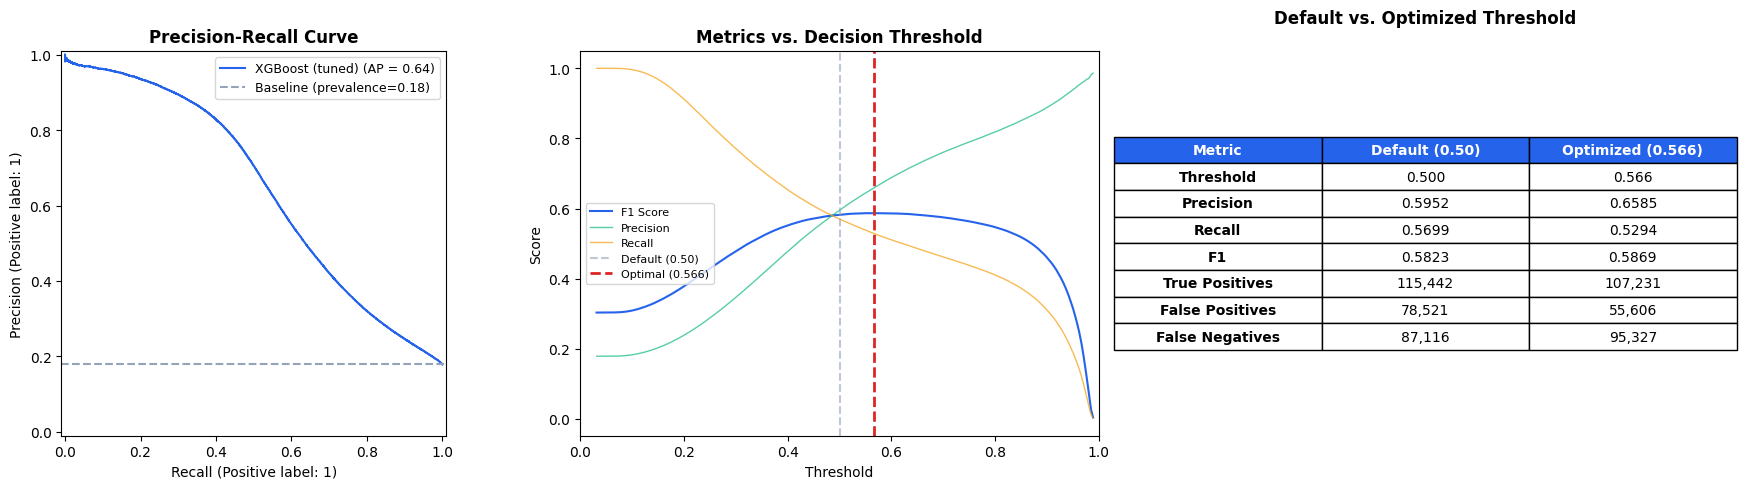

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel A: Precision-Recall curve
ax = axes[0]
PrecisionRecallDisplay.from_predictions(y_test, y_prob_best, name=best_name, ax=ax, color="#2563EB")
ax.axhline(y=y_test.mean(), color="#94A3B8", linestyle="--", label=f"Baseline (prevalence={y_test.mean():.2f})")
ax.set_title("Precision-Recall Curve", fontweight="bold")
ax.legend(loc="upper right", fontsize=9)

# Panel B: F1 vs threshold
ax = axes[1]
# Subsample for smooth plot
step = max(1, len(thresholds_pr) // 500)
ax.plot(thresholds_pr[::step], f1_scores[::step], color="#2563EB", linewidth=1.5, label="F1 Score")
ax.plot(thresholds_pr[::step], precisions[:-1:step], color="#10B981", linewidth=1, alpha=0.7, label="Precision")
ax.plot(thresholds_pr[::step], recalls[:-1:step], color="#F59E0B", linewidth=1, alpha=0.7, label="Recall")
ax.axvline(0.5, color="#94A3B8", linestyle="--", alpha=0.6, label=f"Default (0.50)")
ax.axvline(best_threshold, color="#DC2626", linestyle="--", linewidth=2,
           label=f"Optimal ({best_threshold:.3f})")
ax.set_xlabel("Threshold")
ax.set_ylabel("Score")
ax.set_title("Metrics vs. Decision Threshold", fontweight="bold")
ax.legend(loc="center left", fontsize=8)
ax.set_xlim(0, 1)

# Panel C: Confusion matrix comparison
ax = axes[2]
y_pred_opt = (y_prob_best >= best_threshold).astype(int)
cm_default = confusion_matrix(y_test, y_pred_default)
cm_opt = confusion_matrix(y_test, y_pred_opt)

comparison = pd.DataFrame({
    "Metric": ["Threshold", "Precision", "Recall", "F1", "True Positives", "False Positives", "False Negatives"],
    "Default (0.50)": [
        "0.500",
        f"{prec_default:.4f}",
        f"{rec_default:.4f}",
        f"{f1_default:.4f}",
        f"{cm_default[1,1]:,}",
        f"{cm_default[0,1]:,}",
        f"{cm_default[1,0]:,}",
    ],
    f"Optimized ({best_threshold:.3f})": [
        f"{best_threshold:.3f}",
        f"{best_prec:.4f}",
        f"{best_rec:.4f}",
        f"{best_f1:.4f}",
        f"{cm_opt[1,1]:,}",
        f"{cm_opt[0,1]:,}",
        f"{cm_opt[1,0]:,}",
    ],
})

ax.axis("off")
table = ax.table(
    cellText=comparison.values,
    colLabels=comparison.columns,
    cellLoc="center",
    loc="center",
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.6)
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_facecolor("#2563EB")
        cell.set_text_props(color="white", fontweight="bold")
    elif col == 0:
        cell.set_text_props(fontweight="bold")
ax.set_title("Default vs. Optimized Threshold", fontweight="bold", pad=20)

plt.tight_layout()
plt.savefig(REPORT_DIR / "threshold_optimization.png", dpi=150, bbox_inches="tight")
plt.show()

## Step 7: Confusion matrices — Default vs. Optimized

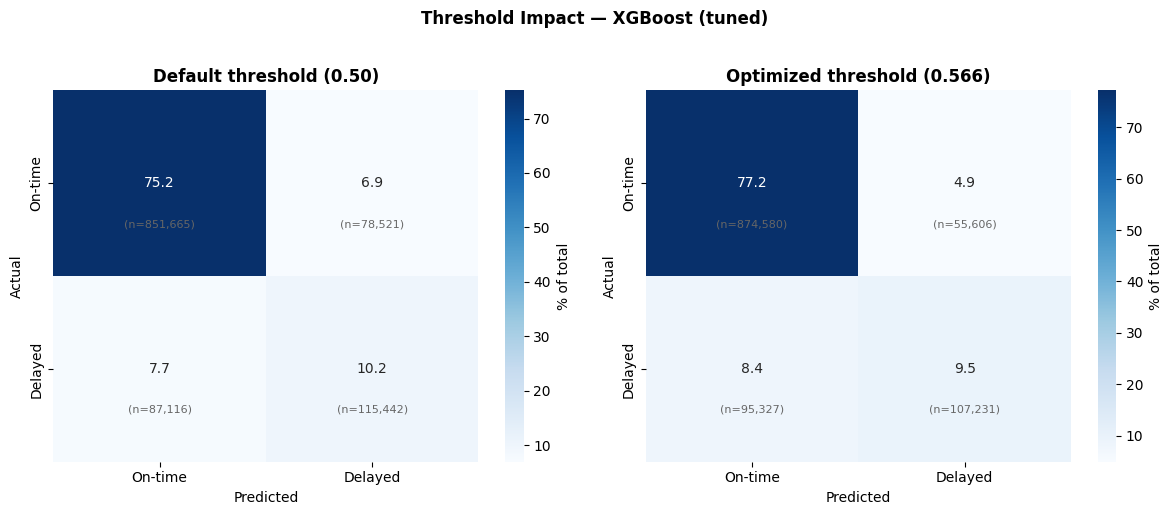

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, y_pred, title in [
    (axes[0], y_pred_default, f"Default threshold (0.50)"),
    (axes[1], y_pred_opt, f"Optimized threshold ({best_threshold:.3f})"),
]:
    cm = confusion_matrix(y_test, y_pred)
    cm_pct = cm / cm.sum() * 100
    sns.heatmap(cm_pct, annot=True, fmt=".1f", cmap="Blues", ax=ax,
                xticklabels=["On-time", "Delayed"],
                yticklabels=["On-time", "Delayed"],
                cbar_kws={"label": "% of total"})
    for i in range(2):
        for j in range(2):
            ax.text(j + 0.5, i + 0.72, f"(n={cm[i,j]:,})",
                    ha="center", va="center", fontsize=8, color="#666")
    ax.set_ylabel("Actual")
    ax.set_xlabel("Predicted")
    ax.set_title(title, fontweight="bold")

plt.suptitle(f"Threshold Impact — {best_name}", fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(REPORT_DIR / "threshold_confusion_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## Step 8: Feature importance — Tuned model

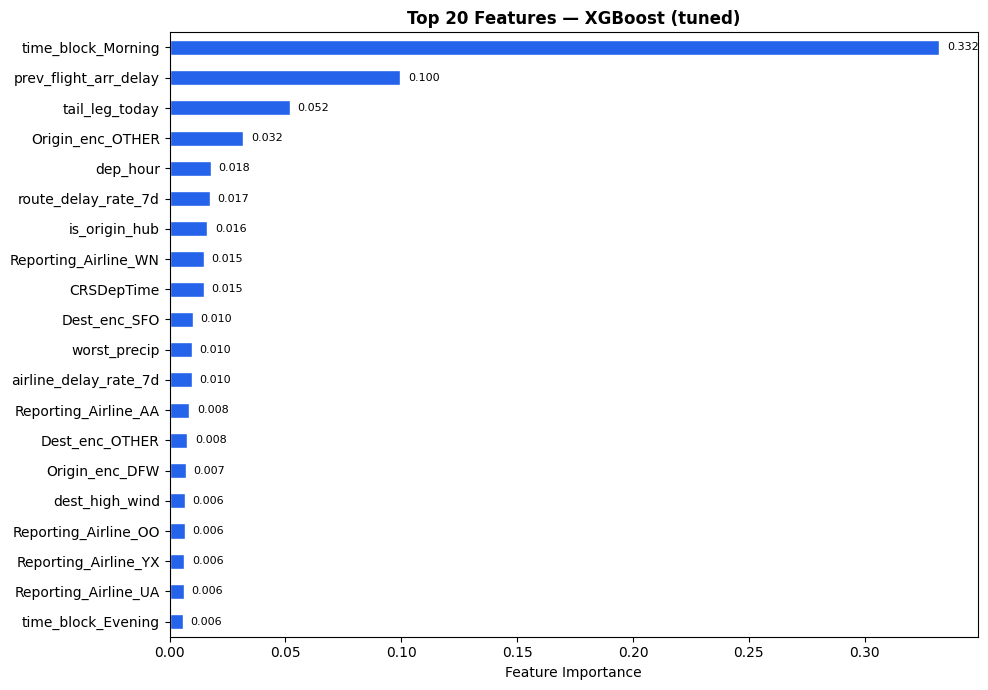

In [13]:
imp = pd.Series(best_model.feature_importances_, index=X_train.columns)
top20 = imp.nlargest(20)

fig, ax = plt.subplots(figsize=(10, 7))
color = "#2563EB" if "XGB" in best_name else "#DC2626"
top20.sort_values().plot.barh(ax=ax, color=color, edgecolor="white")
ax.set_xlabel("Feature Importance")
ax.set_title(f"Top 20 Features — {best_name}", fontweight="bold")
for i, (val, name) in enumerate(zip(top20.sort_values(), top20.sort_values().index)):
    ax.text(val + imp.max() * 0.01, i, f"{val:.0f}" if val > 1 else f"{val:.3f}",
            va="center", fontsize=8)
plt.tight_layout()
plt.savefig(REPORT_DIR / "tuned_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

## Step 9: CV search results

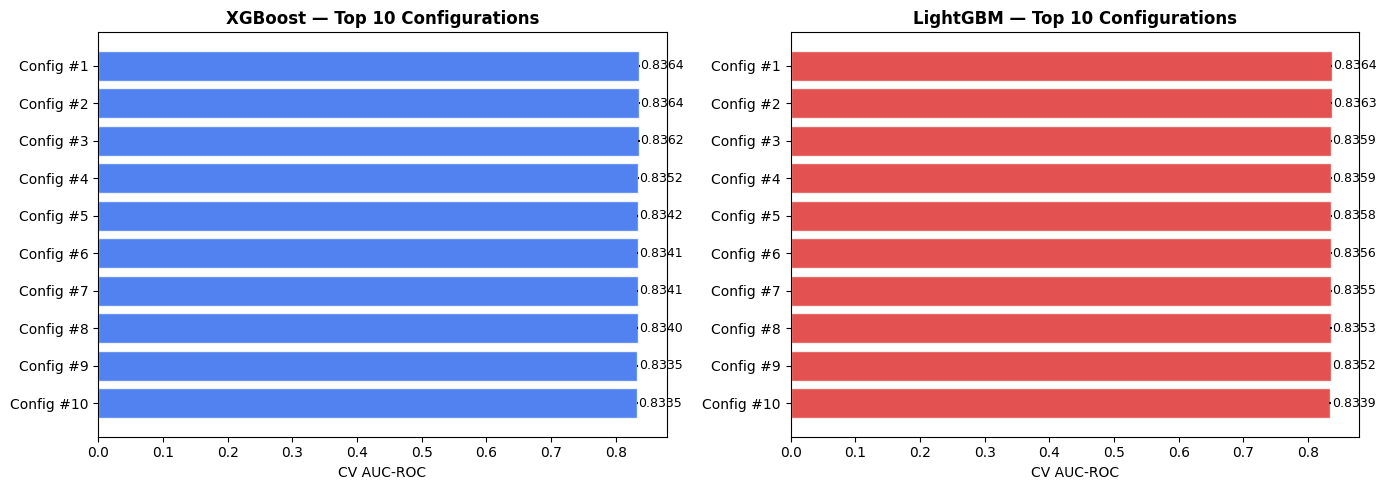

In [14]:
# Show top 10 configurations from each search
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, search, name in [
    (axes[0], xgb_search, "XGBoost"),
    (axes[1], lgbm_search, "LightGBM"),
]:
    results = pd.DataFrame(search.cv_results_)
    results = results.sort_values("rank_test_score")
    top10 = results.head(10)

    ax.barh(range(10), top10["mean_test_score"], xerr=top10["std_test_score"],
            color="#2563EB" if "XGB" in name else "#DC2626", alpha=0.8, edgecolor="white")
    ax.set_yticks(range(10))
    ax.set_yticklabels([f"Config #{i+1}" for i in range(10)])
    ax.set_xlabel("CV AUC-ROC")
    ax.set_title(f"{name} — Top 10 Configurations", fontweight="bold")
    ax.invert_yaxis()
    for i, (score, std) in enumerate(zip(top10["mean_test_score"], top10["std_test_score"])):
        ax.text(score + std + 0.001, i, f"{score:.4f}", va="center", fontsize=9)

plt.tight_layout()
plt.savefig(REPORT_DIR / "tuning_cv_results.png", dpi=150, bbox_inches="tight")
plt.show()

## Step 10: Final model summary

In [15]:
def eval_model(name, y_true, y_pred, y_prob):
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred),
        "AUC-ROC": roc_auc_score(y_true, y_prob),
    }

# Load all previous results
prev_path = REPORT_DIR / "all_model_comparison.csv"
if prev_path.exists():
    prev = pd.read_csv(prev_path)
else:
    prev = pd.DataFrame()

new_results = [
    eval_model("XGBoost (tuned)", y_test, (y_prob_xgb >= 0.5).astype(int), y_prob_xgb),
    eval_model("LightGBM (tuned)", y_test, (y_prob_lgbm >= 0.5).astype(int), y_prob_lgbm),
    eval_model(f"{best_name} (t={best_threshold:.3f})", y_test, y_pred_opt, y_prob_best),
]

all_results = pd.concat([prev, pd.DataFrame(new_results)], ignore_index=True)

print("=" * 90)
print("COMPLETE MODEL COMPARISON — TEST SET (Nov–Dec 2024)")
print("=" * 90)
print(all_results.to_string(index=False, float_format="{:.4f}".format))
print("=" * 90)

best_row = all_results.loc[all_results["AUC-ROC"].idxmax()]
print(f"\nBest AUC-ROC: {best_row['Model']} = {best_row['AUC-ROC']:.4f}")

best_f1_row = all_results.loc[all_results["F1"].idxmax()]
print(f"Best F1:      {best_f1_row['Model']} = {best_f1_row['F1']:.4f}")

all_results.to_csv(REPORT_DIR / "final_model_comparison.csv", index=False)
print(f"\nSaved to {REPORT_DIR / 'final_model_comparison.csv'}")

COMPLETE MODEL COMPARISON — TEST SET (Nov–Dec 2024)
                    Model  Accuracy  Precision  Recall     F1  AUC-ROC
   Naive (always on-time)    0.8212     0.0000  0.0000 0.0000   0.5000
      Logistic Regression    0.8169     0.4879  0.4760 0.4819   0.7553
            Random Forest    0.8532     0.5982  0.5454 0.5706   0.8039
       XGBoost (weighted)    0.8577     0.6125  0.5556 0.5827   0.8151
          XGBoost + SMOTE    0.8783     0.8091  0.4181 0.5513   0.8144
      LightGBM (weighted)    0.8511     0.5852  0.5743 0.5797   0.8169
         LightGBM + SMOTE    0.8777     0.7970  0.4244 0.5539   0.8149
          XGBoost (tuned)    0.8538     0.5952  0.5699 0.5823   0.8194
         LightGBM (tuned)    0.8532     0.5931  0.5704 0.5815   0.8181
XGBoost (tuned) (t=0.566)    0.8668     0.6585  0.5294 0.5869   0.8194

Best AUC-ROC: XGBoost (tuned) = 0.8194
Best F1:      XGBoost (tuned) (t=0.566) = 0.5869

Saved to /Users/jeffvan/Desktop/My Stuff/Courses/CIS5450/CIS-5450/data/report

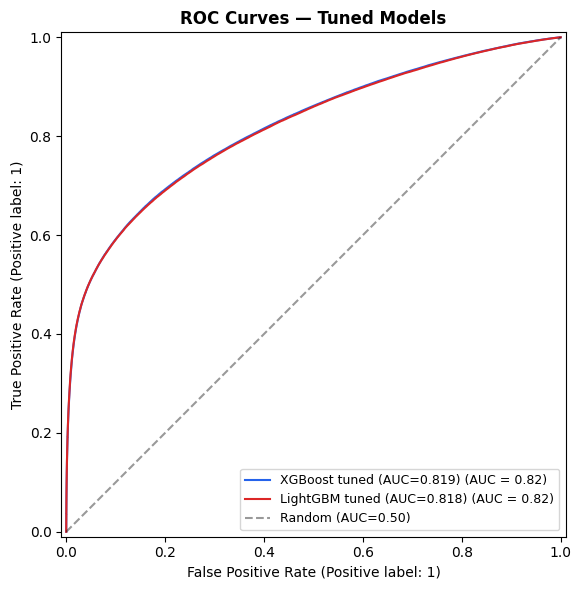

In [16]:
# Final ROC comparison: baseline vs tuned
fig, ax = plt.subplots(figsize=(8, 6))

RocCurveDisplay.from_predictions(y_test, y_prob_xgb, name=f"XGBoost tuned (AUC={auc_xgb:.3f})",
                                  ax=ax, color="#2563EB")
RocCurveDisplay.from_predictions(y_test, y_prob_lgbm, name=f"LightGBM tuned (AUC={auc_lgbm:.3f})",
                                  ax=ax, color="#DC2626")
ax.plot([0, 1], [0, 1], "k--", alpha=0.4, label="Random (AUC=0.50)")
ax.set_title("ROC Curves — Tuned Models", fontweight="bold")
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.savefig(REPORT_DIR / "tuned_roc_curves.png", dpi=150, bbox_inches="tight")
plt.show()

In [17]:
print("=" * 90)
print("HYPERPARAMETER TUNING & THRESHOLD OPTIMIZATION — SUMMARY")
print("=" * 90)
print()
print(f"XGBoost  — CV AUC: {xgb_search.best_score_:.4f} → Test AUC: {auc_xgb:.4f}")
print(f"LightGBM — CV AUC: {lgbm_search.best_score_:.4f} → Test AUC: {auc_lgbm:.4f}")
print()
print(f"Threshold optimization ({best_name}):")
print(f"  Default (0.50):           F1 = {f1_default:.4f}")
print(f"  Optimized ({best_threshold:.3f}):  F1 = {best_f1:.4f}  ({(best_f1-f1_default)*100:+.2f} pp)")
print()
print("Best hyperparameters (XGBoost):")
for k, v in sorted(xgb_search.best_params_.items()):
    print(f"  {k}: {v}")
print()
print("Best hyperparameters (LightGBM):")
for k, v in sorted(lgbm_search.best_params_.items()):
    print(f"  {k}: {v}")
print("=" * 90)

HYPERPARAMETER TUNING & THRESHOLD OPTIMIZATION — SUMMARY

XGBoost  — CV AUC: 0.8364 → Test AUC: 0.8194
LightGBM — CV AUC: 0.8364 → Test AUC: 0.8181

Threshold optimization (XGBoost (tuned)):
  Default (0.50):           F1 = 0.5823
  Optimized (0.566):  F1 = 0.5869  (+0.47 pp)

Best hyperparameters (XGBoost):
  colsample_bytree: 0.7
  learning_rate: 0.05
  max_depth: 6
  min_child_weight: 5
  n_estimators: 400
  reg_alpha: 0
  reg_lambda: 2.0
  subsample: 0.8

Best hyperparameters (LightGBM):
  colsample_bytree: 0.8
  learning_rate: 0.05
  max_depth: 8
  min_child_samples: 20
  n_estimators: 200
  num_leaves: 127
  reg_alpha: 0.1
  reg_lambda: 1.0
  subsample: 0.9
